In [2]:
import sys
import os
project_root = os.path.abspath('../../')
if project_root not in sys.path:
    sys.path.append(project_root)

import yaml
import warnings
warnings.filterwarnings("ignore")

from src.data.discovery import discover_task_files
from src.data.loader import load_task_epochs
from src.visualization.signals import plot_random_epoch

In [ ]:
# Celda 2: Cargar Configuración y Datos
import yaml

with open('../../configs/experiments/data_config.yaml', 'r') as file:
    config = yaml.safe_load(file)

task_df = discover_task_files(config['dataset']['root_dir'])

# 1. Búsqueda exacta al FINAL del nombre del sujeto
mask_nogo = task_df['sujeto'].str.endswith('NG') | task_df['sujeto'].str.endswith('NOGO')
mask_go = task_df['sujeto'].str.endswith('GO') & ~mask_nogo

print(f"Archivos GO encontrados: {mask_go.sum()}")
print(f"Archivos NO-GO encontrados: {mask_nogo.sum()}\n")

if mask_go.sum() == 0 or mask_nogo.sum() == 0:
    print("Muestra de los sujetos encontrados para debug manual:")
    display(task_df['sujeto'].sample(5))
else:
    # 2. Tomar un sujeto Go y un sujeto No-Go
    sample_go = task_df[mask_go].iloc[0]
    sample_nogo = task_df[mask_nogo].iloc[0]

    # 3. Cargar las épocas
    epochs_go = load_task_epochs(sample_go['ruta'], config['dataset']['sampling_rate'], config['channels']['eeg'])
    epochs_nogo = load_task_epochs(sample_nogo['ruta'], config['dataset']['sampling_rate'], config['channels']['eeg'])

    print(f" Sujeto GO cargado exitosamente: {sample_go['sujeto']}")
    print(f" Sujeto NO-GO cargado exitosamente: {sample_nogo['sujeto']}")

Archivos GO encontrados: 59
Archivos NO-GO encontrados: 59

✅ Sujeto GO cargado exitosamente: CJTSGO
✅ Sujeto NO-GO cargado exitosamente: CJTSNG


--- Señal GO ---
Inspeccionando Epoch #1
Using matplotlib as 2D backend.


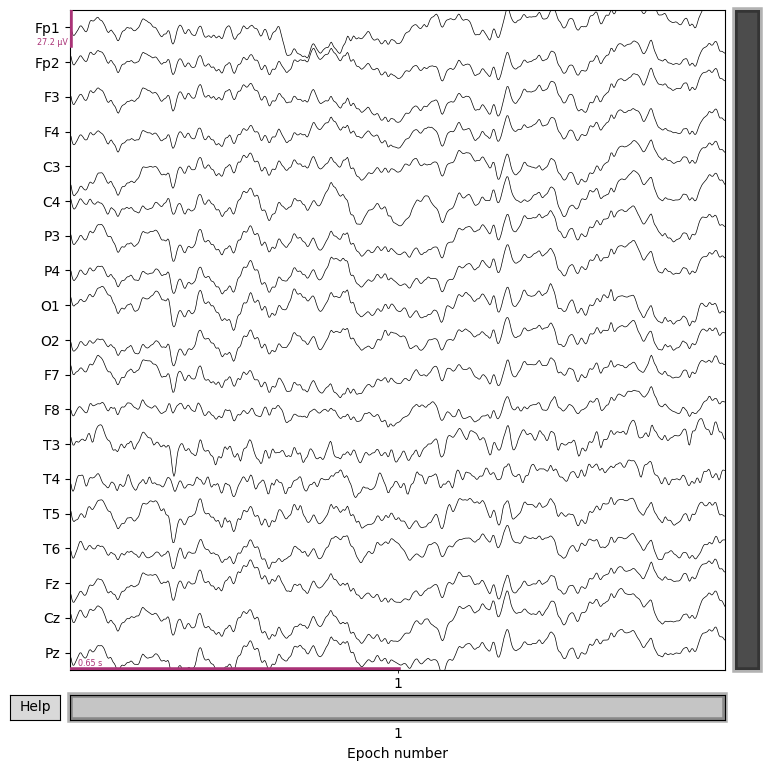

--- Señal NO-GO ---
Inspeccionando Epoch #15


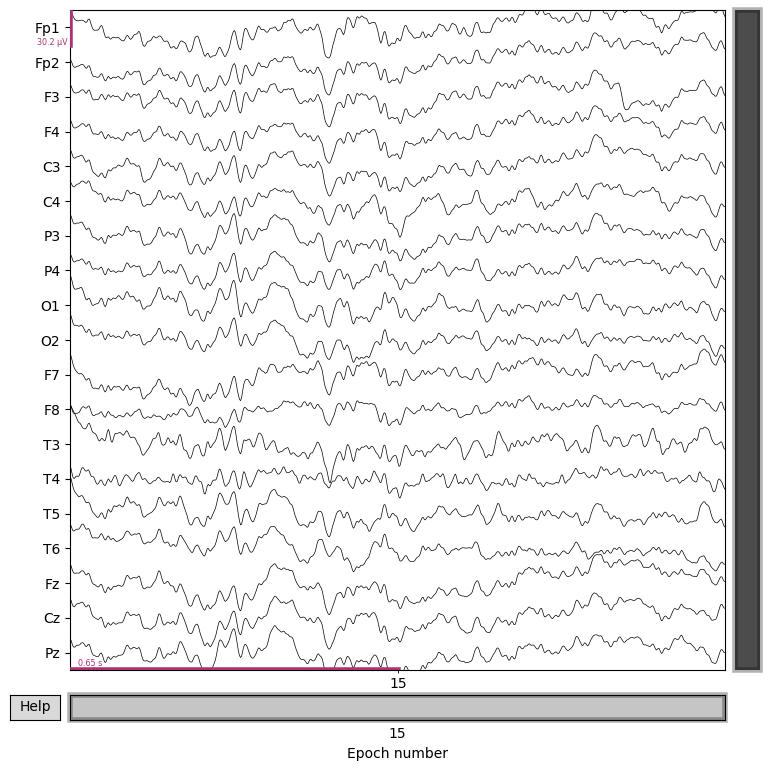

15

In [9]:
print("--- Señal GO ---")
plot_random_epoch(epochs_go, title=f"GO - {sample_go['sujeto']}")

print("--- Señal NO-GO ---")
plot_random_epoch(epochs_nogo, title=f"NOGO - {sample_nogo['sujeto']}")